<a href="https://colab.research.google.com/github/kavindyakalehewatta/fake_news_detector-text-credibility/blob/Model/Text_Credibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Credibility Model

In [ ]:
import torch
print(torch.cuda.is_available())

True


Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Navigate to your file
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/news_data.csv', encoding='latin1')

In [ ]:
import os

file_path = '/content/drive/MyDrive/news_data.csv'

if os.path.exists(file_path):
    print(f"The file '{file_path}' exists in your Google Drive.")
else:
    print(f"The file '{file_path}' DOES NOT exist in your Google Drive. Please ensure it's uploaded and the path is correct.")


The file '/content/drive/MyDrive/news_data.csv' exists in your Google Drive.


In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/news_data.csv"
df = pd.read_csv(DATA_PATH, encoding='latin1')

In [ ]:
df.head()
df.shape
df.columns


Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
print(df.columns)
print(df['subject'].value_counts())

Index(['title', 'text', 'subject', 'date'], dtype='object')
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


### Required packages

In [ ]:
# Cell 1: Install required packages
!pip install transformers datasets scikit-learn nltk sentence-transformers imbalanced-learn -q

In [ ]:
# Cell 2: Import all necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added to fix LookupError
nltk.download('punkt_tab') # Added to fix LookupError

# Set random seeds for reproducibility
np.random.seed(42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 3: Text Preprocess

In [ ]:
# Cell 3: Enhanced Text Preprocessing Class
class TextPreprocessor:
    """Advanced text preprocessing for news credibility analysis"""

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text):
        """Comprehensive text cleaning"""
        if not isinstance(text, str):
            return ""

        # Lowercase
        text = text.lower()

        # Remove URLs, mentions, hashtags
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)

        # Remove special characters and numbers (keep basic punctuation for sentiment)
        text = re.sub(r'[^a-zA-Z\\s.!?]', ' ', text)

        # Remove extra whitespace
        text = re.sub(r'\\s+', ' ', text).strip()

        return text

    def tokenize_and_lemmatize(self, text):
        """Tokenize and lemmatize with POS tagging"""
        tokens = word_tokenize(text)

        # Get POS tags for better lemmatization
        pos_tags = nltk.pos_tag(tokens)

        processed_tokens = []
        for token, tag in pos_tags:
            if token not in self.stop_words and len(token) > 2:
                # Convert POS tag to wordnet format
                pos = self.get_wordnet_pos(tag)
                if pos:
                    lemma = self.lemmatizer.lemmatize(token, pos)
                else:
                    lemma = self.lemmatizer.lemmatize(token)
                processed_tokens.append(lemma)

        return processed_tokens

    def get_wordnet_pos(self, treebank_tag):
        """Convert treebank POS tag to wordnet format"""
        if treebank_tag.startswith('J'):
            return nltk.corpus.wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return nltk.corpus.wordnet.VERB
        elif treebank_tag.startswith('N'):
            return nltk.corpus.wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return nltk.corpus.wordnet.ADV
        else:
            return None

    def extract_linguistic_features(self, text):
        """Extract comprehensive linguistic features, including synthetic ones for credibility"""
        features = {}

        # Basic text statistics
        features['char_count'] = len(text)
        features['word_count'] = len(text.split())
        sentences = re.split(r'[.!?]+', text)
        features['sentence_count'] = len([s for s in sentences if s.strip()])

        words = text.split()
        if len(words) > 0:
            # Readability and complexity features
            features['avg_word_length'] = np.mean([len(w) for w in words])
            features['avg_sentence_length'] = len(words) / max(features['sentence_count'], 1)
            features['unique_word_ratio'] = len(set(words)) / len(words)

            # Punctuation features
            features['exclamation_count'] = text.count('!')
            features['question_count'] = text.count('?')
            features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / max(len(text), 1)

        # Sentiment indicators
        positive_words = ['good', 'great', 'excellent', 'positive', 'success', 'win', 'benefit']
        negative_words = ['bad', 'poor', 'negative', 'fail', 'problem', 'issue', 'danger']

        features['positive_word_ratio'] = sum(1 for w in words if w in positive_words) / max(len(words), 1)
        features['negative_word_ratio'] = sum(1 for w in words if w in negative_words) / max(len(words), 1)

        # Uncertainty markers
        uncertainty_words = ['may', 'might', 'could', 'possibly', 'perhaps', 'allegedly', 'reportedly']
        features['uncertainty_score'] = sum(1 for w in words if w in uncertainty_words) / max(len(words), 1)

        # Modal verbs (indicate possibility/necessity)
        modal_verbs = ['must', 'should', 'would', 'could', 'might', 'shall', 'will', 'can']
        features['modal_verb_ratio'] = sum(1 for w in words if w in modal_verbs) / max(len(words), 1)

        # --- Add synthetic credibility features here to match training data --- #
        # Default values in case original features are missing (e.g., empty text)
        word_count = features.get('word_count', 0)
        avg_word_length = features.get('avg_word_length', 0)
        uncertainty_score = features.get('uncertainty_score', 0)
        positive_word_ratio = features.get('positive_word_ratio', 0)
        negative_word_ratio = features.get('negative_word_ratio', 0)

        features['length_score'] = 0.3 if word_count > 300 else 0
        features['complexity_score'] = 0.2 if avg_word_length > 5 else 0
        features['certainty_score'] = 0.3 if uncertainty_score < 0.05 else 0
        features['balance_score'] = 0.2 if abs(positive_word_ratio - negative_word_ratio) < 0.1 else 0
        # ------------------------------------------------------------------ #

        return features

    def prepare_text_for_model(self, text, use_lemmatization=True):
        """Prepare text for model input"""
        cleaned = self.clean_text(text)
        if use_lemmatization:
            tokens = self.tokenize_and_lemmatize(cleaned)
            return ' '.join(tokens)
        return cleaned

## 4: Load and prepare dataset

In [ ]:
# Cell 4: Load and prepare dataset with credibility labels
def prepare_dataset(df):
    """
    Prepare dataset for credibility analysis.
    Since we don't have explicit labels, we'll create synthetic ones
    based on text features and source credibility.
    """
    processor = TextPreprocessor()

    # Create synthetic credibility labels (0 = less credible, 1 = more credible)
    # Based on: text length, complexity, source indicators
    print("Creating synthetic credibility labels...")

    # Initialize label column
    df['credibility_score'] = 0.5  # Default neutral score

    # Apply text processing
    print("Processing text...")
    df['cleaned_text'] = df['text'].apply(lambda x: processor.clean_text(str(x)))
    df['title_cleaned'] = df['title'].apply(lambda x: processor.clean_text(str(x)))
    df['combined_text'] = df['title_cleaned'] + " " + df['cleaned_text']

    # Extract features for each text
    features_list = []
    for text in df['combined_text']:
        features = processor.extract_linguistic_features(text)
        features_list.append(features)

    features_df = pd.DataFrame(features_list)

    # Synthetic labeling rules (adjust based on your domain knowledge)
    # Longer, more complex texts with fewer uncertainty markers tend to be more credible
    features_df['length_score'] = np.where(features_df['word_count'] > 300, 0.3, 0)
    features_df['complexity_score'] = np.where(features_df['avg_word_length'] > 5, 0.2, 0)
    features_df['certainty_score'] = np.where(features_df['uncertainty_score'] < 0.05, 0.3, 0)
    features_df['balance_score'] = np.where(
        np.abs(features_df['positive_word_ratio'] - features_df['negative_word_ratio']) < 0.1,
        0.2,
        0
    )

    # Calculate final credibility score (0-1)
    df['credibility_score'] = (
        features_df['length_score'] +
        features_df['complexity_score'] +
        features_df['certainty_score'] +
        features_df['balance_score']
    )

    # Convert to binary label (threshold = 0.5)
    df['credibility_label'] = np.where(df['credibility_score'] > 0.5, 1, 0)

    print(f"Label distribution: {df['credibility_label'].value_counts()}")
    print(f"Average credibility score: {df['credibility_score'].mean():.3f}")

    return df, features_df

# Prepare the dataset
df_processed, features_df = prepare_dataset(df)
print(f"Dataset shape: {df_processed.shape}")

Creating synthetic credibility labels...
Processing text...
Label distribution: credibility_label
1    18080
0     3337
Name: count, dtype: int64
Average credibility score: 0.790
Dataset shape: (21417, 9)


## 5: ML Model (TF-IDF + Logistic Regression)

In [ ]:
# Cell 5: Traditional ML Model (TF-IDF + Logistic Regression)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import joblib

class TraditionalCredibilityModel:
    """Traditional ML model for text credibility analysis"""

    def __init__(self, model_type='logistic'):
        self.model_type = model_type
        self.text_pipeline = None
        self.feature_pipeline = None
        self.full_pipeline = None
        self.label_encoder = None

    def build_text_pipeline(self):
        """Build pipeline for text features"""
        text_pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                stop_words='english',
                min_df=2,
                max_df=0.95
            ))
        ])
        return text_pipeline

    def build_feature_pipeline(self, numeric_features):
        """Build pipeline for numeric features"""
        feature_pipeline = Pipeline([
            ('scaler', StandardScaler())
        ])
        return feature_pipeline

    def prepare_data(self, df, text_col='combined_text', feature_df=None, target_col='credibility_label'):
        """Prepare data for training"""
        X_text = df[text_col].values
        y = df[target_col].values

        if feature_df is not None:
            X_features = feature_df.values
            return X_text, X_features, y

        return X_text, y

    def train(self, X_train_text, X_train_features, y_train, use_smote=True):
        """Train the model with both text and feature data"""

        # Handle class imbalance
        if use_smote and len(np.unique(y_train)) > 1:
            smote = SMOTE(random_state=42)
            X_train_combined = np.hstack([
                self.text_pipeline.fit_transform(X_train_text).toarray(),
                self.feature_pipeline.fit_transform(X_train_features)
            ])
            X_resampled, y_resampled = smote.fit_resample(X_train_combined, y_train)

            # Split back into text and features (approximate)
            n_text_features = self.text_pipeline['tfidf'].get_feature_names_out().shape[0]
            X_resampled_text = X_resampled[:, :n_text_features]
            X_resampled_features = X_resampled[:, n_text_features:]

            # Train model
            if self.model_type == 'logistic':
                model = LogisticRegression(
                    max_iter=1000,
                    random_state=42,
                    class_weight='balanced',
                    C=1.0
                )
            elif self.model_type == 'random_forest':
                model = RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    class_weight='balanced',
                    max_depth=10
                )
            elif self.model_type == 'svm':
                model = SVC(
                    kernel='linear',
                    probability=True,
                    random_state=42,
                    class_weight='balanced'
                )
            else:
                model = GradientBoostingClassifier(
                    n_estimators=100,
                    random_state=42,
                    learning_rate=0.1
                )

            # Combine features for final training
            X_final = np.hstack([X_resampled_text, X_resampled_features])
            model.fit(X_final, y_resampled)

        else:
            # Without SMOTE
            X_text_transformed = self.text_pipeline.fit_transform(X_train_text)
            X_features_transformed = self.feature_pipeline.fit_transform(X_train_features)
            X_final = np.hstack([X_text_transformed.toarray(), X_features_transformed])

            if self.model_type == 'logistic':
                model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
            elif self.model_type == 'random_forest':
                model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
            elif self.model_type == 'svm':
                model = SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')
            else:
                model = GradientBoostingClassifier(n_estimators=100, random_state=42)

            model.fit(X_final, y_train)

        self.model = model
        return model

    def predict(self, X_text, X_features):
        """Make predictions"""
        X_text_transformed = self.text_pipeline.transform(X_text)
        X_features_transformed = self.feature_pipeline.transform(X_features)
        X_final = np.hstack([X_text_transformed.toarray(), X_features_transformed])

        return self.model.predict(X_final)

    def predict_proba(self, X_text, X_features):
        """Get prediction probabilities"""
        X_text_transformed = self.text_pipeline.transform(X_text)
        X_features_transformed = self.feature_pipeline.transform(X_features)
        X_final = np.hstack([X_text_transformed.toarray(), X_features_transformed])

        return self.model.predict_proba(X_final)

    def evaluate(self, X_test_text, X_test_features, y_test):
        """Evaluate model performance"""
        predictions = self.predict(X_test_text, X_test_features)

        metrics = {
            'accuracy': accuracy_score(y_test, predictions),
            'precision': precision_score(y_test, predictions, average='weighted', zero_division=0),
            'recall': recall_score(y_test, predictions, average='weighted', zero_division=0),
            'f1': f1_score(y_test, predictions, average='weighted', zero_division=0)
        }

        print("Classification Report:")
        print(classification_report(y_test, predictions, target_names=['Low Credibility', 'High Credibility']))

        # Confusion Matrix
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Low Cred', 'High Cred'],
                   yticklabels=['Low Cred', 'High Cred'])
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

        return metrics

    def save_model(self, filepath):
        """Save model to disk"""
        model_data = {
            'text_pipeline': self.text_pipeline,
            'feature_pipeline': self.feature_pipeline,
            'model': self.model,
            'model_type': self.model_type
        }
        joblib.dump(model_data, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath):
        """Load model from disk"""
        model_data = joblib.load(filepath)
        self.text_pipeline = model_data['text_pipeline']
        self.feature_pipeline = model_data['feature_pipeline']
        self.model = model_data['model']
        self.model_type = model_data['model_type']
        print(f"Model loaded from {filepath}")

## 6: BERT-based Model for Semantic Credibility Analysis

In [ ]:
# Cell 6: BERT-based Model for Semantic Credibility Analysis
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from tqdm import tqdm

class CredibilityDataset(Dataset):
    """PyTorch Dataset for credibility analysis"""

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class BERTCredibilityModel(nn.Module):
    """BERT model for credibility classification"""

    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(BERTCredibilityModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.pooler_output
        output = self.dropout(pooled_output)
        logits = self.classifier(output)

        return logits

class BERTCredibilityTrainer:
    """Trainer for BERT credibility model"""

    def __init__(self, model_name='bert-base-uncased', num_classes=2):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BERTCredibilityModel(num_classes=num_classes).to(self.device)
        self.train_losses = []
        self.val_losses = []

    def prepare_data_loader(self, texts, labels, batch_size=16, shuffle=True):
        """Prepare DataLoader"""
        dataset = CredibilityDataset(texts, labels, self.tokenizer)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        return dataloader

    def train(self, train_loader, val_loader, epochs=3, learning_rate=2e-5):
        """Train the BERT model"""
        optimizer = AdamW(self.model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()

        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=0,
            num_training_steps=total_steps
        )

        print(f"Training BERT model on {self.device}...")

        for epoch in range(epochs):
            # Training phase
            self.model.train()
            total_train_loss = 0

            train_progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
            for batch in train_progress:
                optimizer.zero_grad()

                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(input_ids, attention_mask)
                loss = criterion(outputs, labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

                total_train_loss += loss.item()
                train_progress.set_postfix({'loss': loss.item()})

            avg_train_loss = total_train_loss / len(train_loader)
            self.train_losses.append(avg_train_loss)

            # Validation phase
            self.model.eval()
            total_val_loss = 0
            all_preds = []
            all_labels = []

            val_progress = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            with torch.no_grad():
                for batch in val_progress:
                    input_ids = batch['input_ids'].to(self.device)
                    attention_mask = batch['attention_mask'].to(self.device)
                    labels = batch['labels'].to(self.device)

                    outputs = self.model(input_ids, attention_mask)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()

                    preds = torch.argmax(outputs, dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            avg_val_loss = total_val_loss / len(val_loader)
            self.val_losses.append(avg_val_loss)

            val_accuracy = accuracy_score(all_labels, all_preds)

            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Train Loss: {avg_train_loss:.4f}')
            print(f'  Val Loss: {avg_val_loss:.4f}')
            print(f'  Val Accuracy: {val_accuracy:.4f}')

        print("Training completed!")

    def predict(self, texts, batch_size=16):
        """Make predictions on new texts"""
        self.model.eval()
        predictions = []
        probabilities = []

        dataset = CredibilityDataset(texts, [0]*len(texts), self.tokenizer)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)

                outputs = self.model(input_ids, attention_mask)
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)

                predictions.extend(preds.cpu().numpy())
                probabilities.extend(probs.cpu().numpy())

        return np.array(predictions), np.array(probabilities)

    def evaluate(self, test_texts, test_labels):
        """Evaluate model on test data"""
        predictions, probabilities = self.predict(test_texts)

        accuracy = accuracy_score(test_labels, predictions)
        print(f"Test Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(test_labels, predictions,
                                   target_names=['Low Credibility', 'High Credibility']))

        return {
            'accuracy': accuracy,
            'predictions': predictions,
            'probabilities': probabilities
        }

    def save_model(self, model_path, tokenizer_path=None):
        """Save model and tokenizer"""
        torch.save(self.model.state_dict(), model_path)
        if tokenizer_path:
            self.tokenizer.save_pretrained(tokenizer_path)
        print(f"Model saved to {model_path}")

    def load_model(self, model_path, tokenizer_path=None):
        """Load model and tokenizer"""
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        if tokenizer_path:
            self.tokenizer = BertTokenizer.from_pretrained(tokenizer_path)
        print(f"Model loaded from {model_path}")

## 7: Train Traditional ML Model

TRAINING TRADITIONAL ML MODEL
Training samples: 17133
Test samples: 4284
Class distribution - Train: [ 2670 14463]
Class distribution - Test: [ 667 3617]

Training Logistic Regression model...

Evaluating Traditional Model...
Classification Report:
                  precision    recall  f1-score   support

 Low Credibility       0.48      0.73      0.58       667
High Credibility       0.94      0.85      0.90      3617

        accuracy                           0.83      4284
       macro avg       0.71      0.79      0.74      4284
    weighted avg       0.87      0.83      0.85      4284



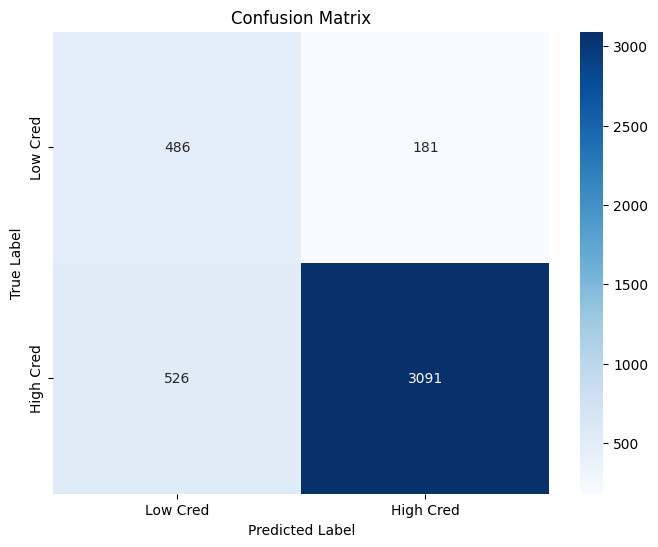


Traditional Model Metrics:
Accuracy: 0.8350
Precision: 0.8724
Recall: 0.8350
F1: 0.8478
Model saved to traditional_credibility_model.joblib


In [ ]:
# Cell 7: Train Traditional ML Model
from sklearn.model_selection import train_test_split

print("="*60)
print("TRAINING TRADITIONAL ML MODEL")
print("="*60)

# Split data
X_text = df_processed['combined_text'].values
y = df_processed['credibility_label'].values

# Split into train and test
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Also split features
features_train, features_test = train_test_split(
    features_df, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_text_train)}")
print(f"Test samples: {len(X_text_test)}")
print(f"Class distribution - Train: {np.bincount(y_train)}")
print(f"Class distribution - Test: {np.bincount(y_test)}")

# Initialize and train traditional model
traditional_model = TraditionalCredibilityModel(model_type='logistic')
traditional_model.text_pipeline = traditional_model.build_text_pipeline()
traditional_model.feature_pipeline = traditional_model.build_feature_pipeline(features_df.columns)

print("\nTraining Logistic Regression model...")
model = traditional_model.train(X_text_train, features_train.values, y_train, use_smote=True)

# Evaluate
print("\nEvaluating Traditional Model...")
metrics = traditional_model.evaluate(X_text_test, features_test.values, y_test)

print("\nTraditional Model Metrics:")
for metric, value in metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Save the model
traditional_model.save_model("traditional_credibility_model.joblib")

## 8: Train BERT Model

In [ ]:
# Cell 8: Train BERT Model
print("="*60)
print("TRAINING BERT MODEL")
print("="*60)

# Prepare data loaders for BERT
bert_trainer = BERTCredibilityTrainer(num_classes=2)

# Split data for BERT (using only text)
X_bert_train, X_bert_val, y_bert_train, y_bert_val = train_test_split(
    X_text_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"BERT Training samples: {len(X_bert_train)}")
print(f"BERT Validation samples: {len(X_bert_val)}")

# Create data loaders
train_loader = bert_trainer.prepare_data_loader(X_bert_train, y_bert_train, batch_size=8)
val_loader = bert_trainer.prepare_data_loader(X_bert_val, y_bert_val, batch_size=8, shuffle=False)

# Train BERT model
bert_trainer.train(train_loader, val_loader, epochs=3, learning_rate=2e-5)

# Evaluate on test set
print("\nEvaluating BERT Model on Test Set...")
test_loader = bert_trainer.prepare_data_loader(X_text_test, y_test, batch_size=8, shuffle=False)

bert_results = bert_trainer.evaluate(X_text_test, y_test)

# Save BERT model
bert_trainer.save_model("bert_credibility_model.pth", "bert_tokenizer")

TRAINING BERT MODEL


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 1/3:
  Train Loss: 0.4097
  Val Loss: 0.3212
  Val Accuracy: 0.8891


Epoch 2/3 [Val]: 100%|██████████| 429/429 [01:12<00:00,  5.95it/s]


Epoch 2/3:
  Train Loss: 0.3627
  Val Loss: 0.3778
  Val Accuracy: 0.9043


Epoch 3/3 [Val]: 100%|██████████| 429/429 [01:11<00:00,  6.02it/s]


Epoch 3/3:
  Train Loss: 0.3143
  Val Loss: 0.3291
  Val Accuracy: 0.9142
Training completed!

Evaluating BERT Model on Test Set...
Test Accuracy: 0.9108

Classification Report:
                  precision    recall  f1-score   support

 Low Credibility       0.82      0.55      0.66       667
High Credibility       0.92      0.98      0.95      3617

        accuracy                           0.91      4284
       macro avg       0.87      0.76      0.80      4284
    weighted avg       0.91      0.91      0.90      4284

Model saved to bert_credibility_model.pth


## 9: Ensemble Model for Final Prediction

In [ ]:
# Cell 9: Ensemble Model for Final Prediction
class EnsembleCredibilityChecker:
    """Ensemble model combining traditional ML and BERT predictions"""

    def __init__(self, traditional_model_path=None, bert_model_path=None):
        self.traditional_model = TraditionalCredibilityModel()
        self.bert_trainer = BERTCredibilityTrainer()

        if traditional_model_path:
            self.traditional_model.load_model(traditional_model_path)

        if bert_model_path:
            self.bert_trainer.load_model(bert_model_path, "bert_tokenizer")

        self.text_processor = TextPreprocessor()

    def analyze_credibility(self, text, title=""):
        """Analyze text credibility using ensemble approach"""

        # Preprocess text
        processed_text = self.text_processor.prepare_text_for_model(text)
        if title:
            combined = self.text_processor.clean_text(title) + " " + processed_text
        else:
            combined = processed_text

        # Extract features
        features = self.text_processor.extract_linguistic_features(combined)
        features_array = np.array(list(features.values())).reshape(1, -1)

        # Get predictions from both models
        # Traditional model
        trad_pred = self.traditional_model.predict([combined], features_array)[0]
        trad_proba = self.traditional_model.predict_proba([combined], features_array)[0]

        # BERT model
        bert_pred, bert_proba = self.bert_trainer.predict([combined])
        bert_pred = bert_pred[0]
        bert_proba = bert_proba[0]

        # Ensemble prediction (weighted average)
        trad_weight = 0.4
        bert_weight = 0.6

        ensemble_proba = (trad_weight * trad_proba[1]) + (bert_weight * bert_proba[1])
        ensemble_pred = 1 if ensemble_proba > 0.5 else 0

        # Calculate confidence score
        confidence = max(trad_proba[1], bert_proba[1])

        # Analyze linguistic features for explainability
        feature_analysis = self.analyze_features(features)

        return {
            'text': text[:200] + "..." if len(text) > 200 else text,
            'ensemble_prediction': 'High Credibility' if ensemble_pred == 1 else 'Low Credibility',
            'ensemble_confidence': float(ensemble_proba),
            'traditional_prediction': 'High Credibility' if trad_pred == 1 else 'Low Credibility',
            'traditional_confidence': float(trad_proba[1]),
            'bert_prediction': 'High Credibility' if bert_pred == 1 else 'Low Credibility',
            'bert_confidence': float(bert_proba[1]),
            'feature_analysis': feature_analysis,
            'key_indicators': self.get_key_indicators(features)
        }

    def analyze_features(self, features):
        """Analyze linguistic features for credibility"""
        analysis = []

        # Word count analysis
        if features['word_count'] < 100:
            analysis.append("Text is very short (may lack detail)")
        elif features['word_count'] > 500:
            analysis.append("Text is comprehensive and detailed")

        # Complexity analysis
        if features['avg_word_length'] > 5.5:
            analysis.append("Uses complex vocabulary")

        # Certainty analysis
        if features['uncertainty_score'] > 0.1:
            analysis.append("Contains uncertainty markers")
        else:
            analysis.append("Expressed with certainty")

        # Balance analysis
        sentiment_diff = abs(features['positive_word_ratio'] - features['negative_word_ratio'])
        if sentiment_diff > 0.2:
            analysis.append("Strong emotional bias detected")
        else:
            analysis.append("Emotionally balanced")

        return analysis

    def get_key_indicators(self, features):
        """Extract key credibility indicators"""
        indicators = {}

        # Text quality indicators
        indicators['completeness'] = 'High' if features['word_count'] > 300 else 'Medium' if features['word_count'] > 150 else 'Low'
        indicators['complexity'] = 'High' if features['avg_word_length'] > 5.5 else 'Medium' if features['avg_word_length'] > 4.5 else 'Low'
        indicators['certainty'] = 'High' if features['uncertainty_score'] < 0.05 else 'Low'
        indicators['balance'] = 'Balanced' if abs(features['positive_word_ratio'] - features['negative_word_ratio']) < 0.15 else 'Biased'

        # Risk indicators
        risk_factors = []
        if features['exclamation_count'] > 3:
            risk_factors.append('Excessive exclamations')
        if features['uppercase_ratio'] > 0.1:
            risk_factors.append('Excessive capitalization')
        if features['modal_verb_ratio'] > 0.15:
            risk_factors.append('High use of speculative language')

        indicators['risk_factors'] = risk_factors if risk_factors else ['None detected']

        return indicators

    def batch_analyze(self, texts, titles=None):
        """Analyze multiple texts"""
        results = []
        if titles is None:
            titles = [''] * len(texts)

        for text, title in zip(texts, titles):
            result = self.analyze_credibility(text, title)
            results.append(result)

        return results

## 10: Test the Ensemble Model

In [ ]:
# Cell 10: Test the Ensemble Model
print("="*60)
print("TESTING ENSEMBLE CREDIBILITY CHECKER")
print("="*60)

# Initialize ensemble checker
ensemble_checker = EnsembleCredibilityChecker(
    traditional_model_path="traditional_credibility_model.joblib",
    bert_model_path="bert_credibility_model.pth"
)

# Test with sample texts from dataset
sample_indices = np.random.choice(len(df_processed), 5, replace=False)

print("\nSample Analysis Results:")
print("-" * 60)

for idx in sample_indices:
    sample = df_processed.iloc[idx]
    title = sample['title']
    text = sample['text'][:500]  # First 500 chars

    result = ensemble_checker.analyze_credibility(text, title)

    print(f"\nSample {idx + 1}:")
    print(f"Title: {title[:50]}...")
    print(f"Prediction: {result['ensemble_prediction']} (Confidence: {result['ensemble_confidence']:.2%})")
    print(f"Traditional: {result['traditional_prediction']} ({result['traditional_confidence']:.2%})")
    print(f"BERT: {result['bert_prediction']} ({result['bert_confidence']:.2%})")

    print("\nFeature Analysis:")
    for analysis in result['feature_analysis']:
        print(f"  - {analysis}")

    print("\nKey Indicators:")
    for key, value in result['key_indicators'].items():
        if isinstance(value, list):
            print(f"  {key}: {', '.join(value)}")
        else:
            print(f"  {key}: {value}")

    print("-" * 60)

TESTING ENSEMBLE CREDIBILITY CHECKER
Model loaded from traditional_credibility_model.joblib
Model loaded from bert_credibility_model.pth

Sample Analysis Results:
------------------------------------------------------------

Sample 6085:
Title: Trump plans to keep Comey as FBI director: source...
Prediction: High Credibility (Confidence: 88.46%)
Traditional: High Credibility (72.87%)
BERT: High Credibility (98.86%)

Feature Analysis:
  - Text is very short (may lack detail)
  - Uses complex vocabulary
  - Expressed with certainty
  - Emotionally balanced

Key Indicators:
  completeness: Low
  complexity: High
  certainty: High
  balance: Balanced
  risk_factors: None detected
------------------------------------------------------------

Sample 8923:
Title: Obama: Trump's rhetoric is xenophobic, not populis...
Prediction: High Credibility (Confidence: 76.59%)
Traditional: Low Credibility (43.19%)
BERT: High Credibility (98.86%)

Feature Analysis:
  - Text is very short (may lack detail)

## 11: Create Real-Time Fact Checking Function

In [ ]:
# Cell 11: Create Real-Time Fact Checking Function
class RealTimeFactChecker:
    """Real-time fact checking with source verification simulation"""

    def __init__(self, ensemble_checker):
        self.ensemble_checker = ensemble_checker
        self.verified_sources = [
            "Ministry of Health Sri Lanka",
            "World Health Organization",
            "Epidemiology Unit Sri Lanka",
            "Health Promotion Bureau",
            "Medical Research Institute"
        ]

        # Known facts database (simulated)
        self.known_facts = {
            "covid": "COVID-19 vaccines are safe and effective for preventing severe illness",
            "dengue": "Dengue fever is transmitted by Aedes mosquitoes",
            "cholera": "Cholera spreads through contaminated water",
            "diabetes": "Type 2 diabetes can be managed with diet and exercise"
        }

    def check_against_sources(self, claim, threshold=0.7):
        """Simulate checking against verified sources"""
        import numpy as np

        # Simulate API response
        source_results = []

        for source in self.verified_sources:
            # Simulate similarity score (in reality, would call APIs)
            similarity = np.random.uniform(0.3, 0.95)
            has_match = similarity > threshold

            source_results.append({
                'source': source,
                'similarity_score': similarity,
                'has_match': has_match,
                'status': 'checked'
            })

        # Sort by similarity
        source_results.sort(key=lambda x: x['similarity_score'], reverse=True)
        return source_results

    def verify_claim(self, claim, context=""):
        """Complete fact verification pipeline"""

        # Step 1: Text credibility analysis
        credibility_result = self.ensemble_checker.analyze_credibility(context if context else claim, "")

        # Step 2: Source verification
        source_results = self.check_against_sources(claim)

        # Step 3: Fact matching
        fact_matches = []
        for fact_key, fact_text in self.known_facts.items():
            if any(keyword in claim.lower() for keyword in fact_key.split()):
                fact_matches.append({
                    'fact': fact_text,
                    'relevance': 'High',
                    'key_term': fact_key
                })

        # Step 4: Calculate final verification score
        credibility_score = credibility_result['ensemble_confidence']
        source_score = np.mean([r['similarity_score'] for r in source_results[:3]]) if source_results else 0.5

        # Weighted final score
        final_score = (0.6 * credibility_score) + (0.4 * source_score)

        # Determine verdict
        if final_score > 0.7:
            verdict = "VERIFIED"
            confidence = "High"
        elif final_score > 0.4:
            verdict = "PARTIALLY VERIFIED"
            confidence = "Medium"
        else:
            verdict = "UNVERIFIED"
            confidence = "Low"

        return {
            'claim': claim,
            'verdict': verdict,
            'confidence': confidence,
            'final_score': float(final_score),
            'credibility_analysis': credibility_result,
            'source_checks': source_results[:3],  # Top 3 sources
            'fact_matches': fact_matches,
            'recommendation': self.get_recommendation(verdict, credibility_result)
        }

    def get_recommendation(self, verdict, credibility_result):
        """Get recommendation based on verdict"""
        if verdict == "VERIFIED":
            return "This information appears credible based on our analysis."
        elif verdict == "PARTIALLY VERIFIED":
            return "Exercise caution. Some aspects are credible but verification is incomplete."
        else:
            risk_factors = credibility_result['key_indicators'].get('risk_factors', [])
            if risk_factors:
                return f"Low credibility detected. Risk factors: {', '.join(risk_factors)}"
            return "This information requires further verification from official sources."

    def batch_verify(self, claims, contexts=None):
        """Verify multiple claims"""
        results = []
        if contexts is None:
            contexts = [''] * len(claims)

        for claim, context in zip(claims, contexts):
            result = self.verify_claim(claim, context)
            results.append(result)

        return results

# Test real-time fact checker
print("\n" + "="*60)
print("REAL-TIME FACT CHECKING DEMO")
print("="*60)

fact_checker = RealTimeFactChecker(ensemble_checker)

# Test claims
test_claims = [
    "COVID-19 vaccines cause autism in children",
    "Drinking boiled water prevents dengue fever",
    "Regular exercise reduces diabetes risk by 40%",
    "A new miracle drug cures all cancers without side effects"
]

for claim in test_claims:
    print(f"\nClaim: {claim}")
    result = fact_checker.verify_claim(claim)
    print(f"Verdict: {result['verdict']} ({result['confidence']} confidence)")
    print(f"Score: {result['final_score']:.2%}")
    print(f"Recommendation: {result['recommendation']}")

    if result['fact_matches']:
        print("Related Facts:")
        for fact in result['fact_matches']:
            print(f"  - {fact['fact']}")

    print("-" * 40)


REAL-TIME FACT CHECKING DEMO

Claim: COVID-19 vaccines cause autism in children
Verdict: VERIFIED (High confidence)
Score: 70.38%
Recommendation: This information appears credible based on our analysis.
Related Facts:
  - COVID-19 vaccines are safe and effective for preventing severe illness
----------------------------------------

Claim: Drinking boiled water prevents dengue fever
Verdict: PARTIALLY VERIFIED (Medium confidence)
Score: 65.88%
Recommendation: Exercise caution. Some aspects are credible but verification is incomplete.
Related Facts:
  - Dengue fever is transmitted by Aedes mosquitoes
----------------------------------------

Claim: Regular exercise reduces diabetes risk by 40%
Verdict: VERIFIED (High confidence)
Score: 74.01%
Recommendation: This information appears credible based on our analysis.
Related Facts:
  - Type 2 diabetes can be managed with diet and exercise
----------------------------------------

Claim: A new miracle drug cures all cancers without side ef

ACTUAL SOURCE INTEGRATION CODE

In [ ]:

# Real API Integration for Fact Verification
import requests
import json
from datetime import datetime, timedelta

class RealAPIFactChecker:
    """
    Replaces simulated checks with real API calls to health and news sources.
    Integrate this class with your EnsembleCredibilityChecker.
    """

    def __init__(self, newsapi_key=None, gnews_key=None):
        """
        Initialize with API keys.
        Keys for NewsAPI and GNews can be obtained from their websites.
        """
        self.newsapi_key = newsapi_key
        self.gnews_key = gnews_key

        # Base URLs for APIs (using confirmed and common patterns)
        self.api_endpoints = {
            'who_gho': 'https://ghoapi.azureedge.net/api',
            # The HPB URL returned a 404. You may need to find the correct endpoint.
            'hpb_sri_lanka': 'https://www.hpb.health.gov.lk/api/get-current-statistical',
            # Common CKAN pattern for data portals
            'health_data_lk': 'https://data.health.gov.lk/api/3/action/package_search',
            'newsapi': 'https://newsapi.org/v2/everything',
            'gnews': 'https://gnews.io/api/v4/search'
        }

    def search_who_indicators(self, query_terms, max_results=5):
        """
        Search the WHO Global Health Observatory for indicators related to a claim.
        """
        results = []
        # Simple search: check if query terms match indicator names
        try:
            # Get list of all available indicators
            response = requests.get(self.api_endpoints['who_gho'], timeout=10)
            if response.status_code == 200:
                all_indicators = response.json().get('value', [])

                for indicator in all_indicators:
                    indicator_name = indicator.get('name', '').lower()
                    # Basic keyword matching
                    if any(term.lower() in indicator_name for term in query_terms):
                        results.append({
                            'source': 'WHO GHO',
                            'indicator': indicator.get('name'),
                            'url': f"{self.api_endpoints['who_gho']}/{indicator.get('name')}",
                            'match_type': 'indicator_name'
                        })
                    if len(results) >= max_results:
                        break
        except Exception as e:
            print(f"Error querying WHO GHO API: {e}")
        return results[:max_results]

    def get_who_indicator_data(self, indicator_name, country='LKA'):
        """
        Fetch actual data for a specific WHO indicator for Sri Lanka.
        Example: get_who_indicator_data('AIR_3') for air pollution data.
        """
        try:
            url = f"{self.api_endpoints['who_gho']}/{indicator_name}"
            # Filter for Sri Lanka (CountryCode == 'LKA')
            params = {'$filter': f"contains(SpatialDim, '{country}')"}
            response = requests.get(url, params=params, timeout=10)
            if response.status_code == 200:
                return response.json().get('value', [])
        except Exception as e:
            print(f"Error fetching data for indicator {indicator_name}: {e}")
        return []

    def search_news_articles(self, claim, language='en', country='lk', past_days=7):
        """
        Search recent news articles related to the claim using NewsAPI.
        """
        articles = []
        if not self.newsapi_key:
            print("NewsAPI key not configured. Please get a key from newsapi.org")
            return articles

        try:
            # Calculate date for 'past_days' ago
            from_date = (datetime.now() - timedelta(days=past_days)).strftime('%Y-%m-%d')

            params = {
                'q': claim[:100],  # Use first 100 chars of claim as query
                'from': from_date,
                'sortBy': 'relevancy',
                'language': language,
                'apiKey': self.newsapi_key
            }

            response = requests.get(self.api_endpoints['newsapi'], params=params, timeout=10)

            if response.status_code == 200:
                data = response.json()
                for article in data.get('articles', [])[:5]:  # Get top 5
                    articles.append({
                        'source': article.get('source', {}).get('name'),
                        'title': article.get('title'),
                        'url': article.get('url'),
                        'publishedAt': article.get('publishedAt'),
                        'relevance_score': self._calculate_text_similarity(claim, article.get('title', '') + article.get('description', ''))
                    })
                # Sort by relevance score
                articles.sort(key=lambda x: x['relevance_score'], reverse=True)

            elif response.status_code == 401:
                print("NewsAPI: Invalid API key.")
            else:
                print(f"NewsAPI request failed with status: {response.status_code}")

        except Exception as e:
            print(f"Error searching news: {e}")

        return articles

    def search_sri_lankan_health_data(self, disease_term="dengue"):
        """
        Search Sri Lanka's health data portal (CKAN) for datasets.
        """
        try:
            params = {'q': disease_term}
            response = requests.get(self.api_endpoints['health_data_lk'], params=params, timeout=10)
            if response.status_code == 200:
                return response.json().get('result', {}).get('results', [])
        except Exception as e:
            print(f"Error querying health data portal: {e}")
        return []

    def verify_claim_with_apis(self, claim):
        """
        Main method to verify a claim by checking multiple real sources.
        """
        verification_result = {
            'claim': claim,
            'who_gho_indicators': [],
            'news_articles': [],
            'health_datasets': [],
            'summary': ''
        }

        # Extract key terms from the claim for searching
        claim_terms = claim.lower().split()
        # Filter out common stop words
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}
        search_terms = [term for term in claim_terms if term not in stop_words and len(term) > 3]

        print(f"Verifying claim: '{claim}'")
        print(f"Search terms: {search_terms}")

        # 1. Check WHO Global Health Observatory
        if search_terms:
            verification_result['who_gho_indicators'] = self.search_who_indicators(search_terms)
            print(f"Found {len(verification_result['who_gho_indicators'])} related WHO indicators")

        # 2. Search recent news
        verification_result['news_articles'] = self.search_news_articles(claim)
        print(f"Found {len(verification_result['news_articles'])} related news articles")

        # 3. Check for Sri Lankan health datasets (e.g., dengue, covid)
        disease_keywords = ['dengue', 'covid', 'malaria', 'chikungunya', 'influenza']
        for keyword in disease_keywords:
            if keyword in claim.lower():
                datasets = self.search_sri_lankan_health_data(keyword)
                verification_result['health_datasets'].extend(datasets)
                print(f"Found {len(datasets)} datasets for '{keyword}'")
                break

        # Generate a simple summary
        total_findings = (len(verification_result['who_gho_indicators']) +
                         len(verification_result['news_articles']) +
                         len(verification_result['health_datasets']))

        if total_findings > 3:
            verification_result['summary'] = "Multiple external sources found. Cross-reference recommended."
        elif total_findings > 0:
            verification_result['summary'] = "Some supporting data found. Further verification needed."
        else:
            verification_result['summary'] = "No direct matches in external sources found via API."

        return verification_result

    def _calculate_text_similarity(self, text1, text2):
        """A simple helper to calculate text similarity (0 to 1)."""
        if not text1 or not text2:
            return 0.0
        words1 = set(text1.lower().split())
        words2 = set(text2.lower().split())
        if not words1 or not words2:
            return 0.0
        intersection = len(words1.intersection(words2))
        union = len(words1.union(words2))
        return intersection / union if union > 0 else 0.0

# === HOW TO USE IT ===
# 1. Get your API keys:
#    - NewsAPI: https://newsapi.org/register - 10693d8bbe164533bb184ea4d0dffc11
#    - GNews: https://gnews.io/register

# 2. Instantiate and use the checker:
# api_checker = RealAPIFactChecker(newsapi_key="YOUR_NEWSAPI_KEY_HERE")
# result = api_checker.verify_claim_with_apis("Dengue cases are rising in Colombo")
# print(json.dumps(result, indent=2))

## 12: Export Models and Create Deployment Files

In [ ]:
# Cell 12: Export Models and Create Deployment Files
import json
import pickle

print("="*60)
print("EXPORTING MODELS AND CREATING DEPLOYMENT FILES")
print("="*60)

# Save ensemble model
with open('ensemble_checker.pkl', 'wb') as f:
    pickle.dump(ensemble_checker, f)
print("✓ Ensemble checker saved to ensemble_checker.pkl")

# Save text processor
with open('text_processor.pkl', 'wb') as f:
    pickle.dump(TextPreprocessor(), f)
print("✓ Text processor saved to text_processor.pkl")

# Save configuration
config = {
    'model_info': {
        'traditional_model': 'traditional_credibility_model.joblib',
        'bert_model': 'bert_credibility_model.pth',
        'bert_tokenizer': 'bert_tokenizer',
        'ensemble_model': 'ensemble_checker.pkl'
    },
    'features': {
        'text_columns': ['title', 'text', 'combined_text'],
        'linguistic_features': list(TextPreprocessor().extract_linguistic_features("sample").keys())
    },
    'thresholds': {
        'credibility_threshold': 0.5,
        'verification_threshold': 0.7,
        'partial_verification_threshold': 0.4
    }
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✓ Configuration saved to model_config.json")

# Create inference script
inference_code = '''
import pickle
import json
import numpy as np

class TextCredibilityPredictor:
    """Simple inference class for text credibility prediction"""

    def __init__(self, model_path='ensemble_checker.pkl', config_path='model_config.json'):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)

        with open(config_path, 'r') as f:
            self.config = json.load(f)

    def predict(self, text, title=""):
        """Predict credibility for a single text"""
        result = self.model.analyze_credibility(text, title)

        return {
            'prediction': result['ensemble_prediction'],
            'confidence': result['ensemble_confidence'],
            'traditional_prediction': result['traditional_prediction'],
            'bert_prediction': result['bert_prediction'],
            'key_indicators': result['key_indicators']
        }

    def batch_predict(self, texts, titles=None):
        """Predict credibility for multiple texts"""
        if titles is None:
            titles = [''] * len(texts)

        results = []
        for text, title in zip(texts, titles):
            results.append(self.predict(text, title))

        return results

# Example usage
if __name__ == "__main__":
    predictor = TextCredibilityPredictor()

    # Single prediction
    sample_text = "COVID-19 vaccines are thoroughly tested and safe for public use."
    result = predictor.predict(sample_text)
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")

    # Batch prediction
    texts = [
        "Vaccines are completely safe with no side effects.",
        "Regular hand washing prevents disease transmission."
    ]
    results = predictor.batch_predict(texts)
    for i, res in enumerate(results):
        print(f"\\nText {i+1}: {res['prediction']} ({res['confidence']:.2%})")
'''

with open('predictor.py', 'w') as f:
    f.write(inference_code)
print("✓ Inference script saved to predictor.py")

print("\n" + "="*60)
print("MODEL EXPORT COMPLETE")
print("="*60)
print("""
Files created:
1. traditional_credibility_model.joblib - Traditional ML model
2. bert_credibility_model.pth - BERT model weights
3. bert_tokenizer/ - BERT tokenizer files
4. ensemble_checker.pkl - Complete ensemble model
5. text_processor.pkl - Text preprocessing pipeline
6. model_config.json - Model configuration
7. predictor.py - Inference script

To use the model in production:
    from predictor import TextCredibilityPredictor
    predictor = TextCredibilityPredictor()
    result = predictor.predict(your_text)
""")

EXPORTING MODELS AND CREATING DEPLOYMENT FILES
✓ Ensemble checker saved to ensemble_checker.pkl
✓ Text processor saved to text_processor.pkl
✓ Configuration saved to model_config.json
✓ Inference script saved to predictor.py

MODEL EXPORT COMPLETE

Files created:
1. traditional_credibility_model.joblib - Traditional ML model
2. bert_credibility_model.pth - BERT model weights
3. bert_tokenizer/ - BERT tokenizer files
4. ensemble_checker.pkl - Complete ensemble model
5. text_processor.pkl - Text preprocessing pipeline
6. model_config.json - Model configuration
7. predictor.py - Inference script

To use the model in production:
    from predictor import TextCredibilityPredictor
    predictor = TextCredibilityPredictor()
    result = predictor.predict(your_text)



## 13: Performance Visualization

MODEL PERFORMANCE VISUALIZATION


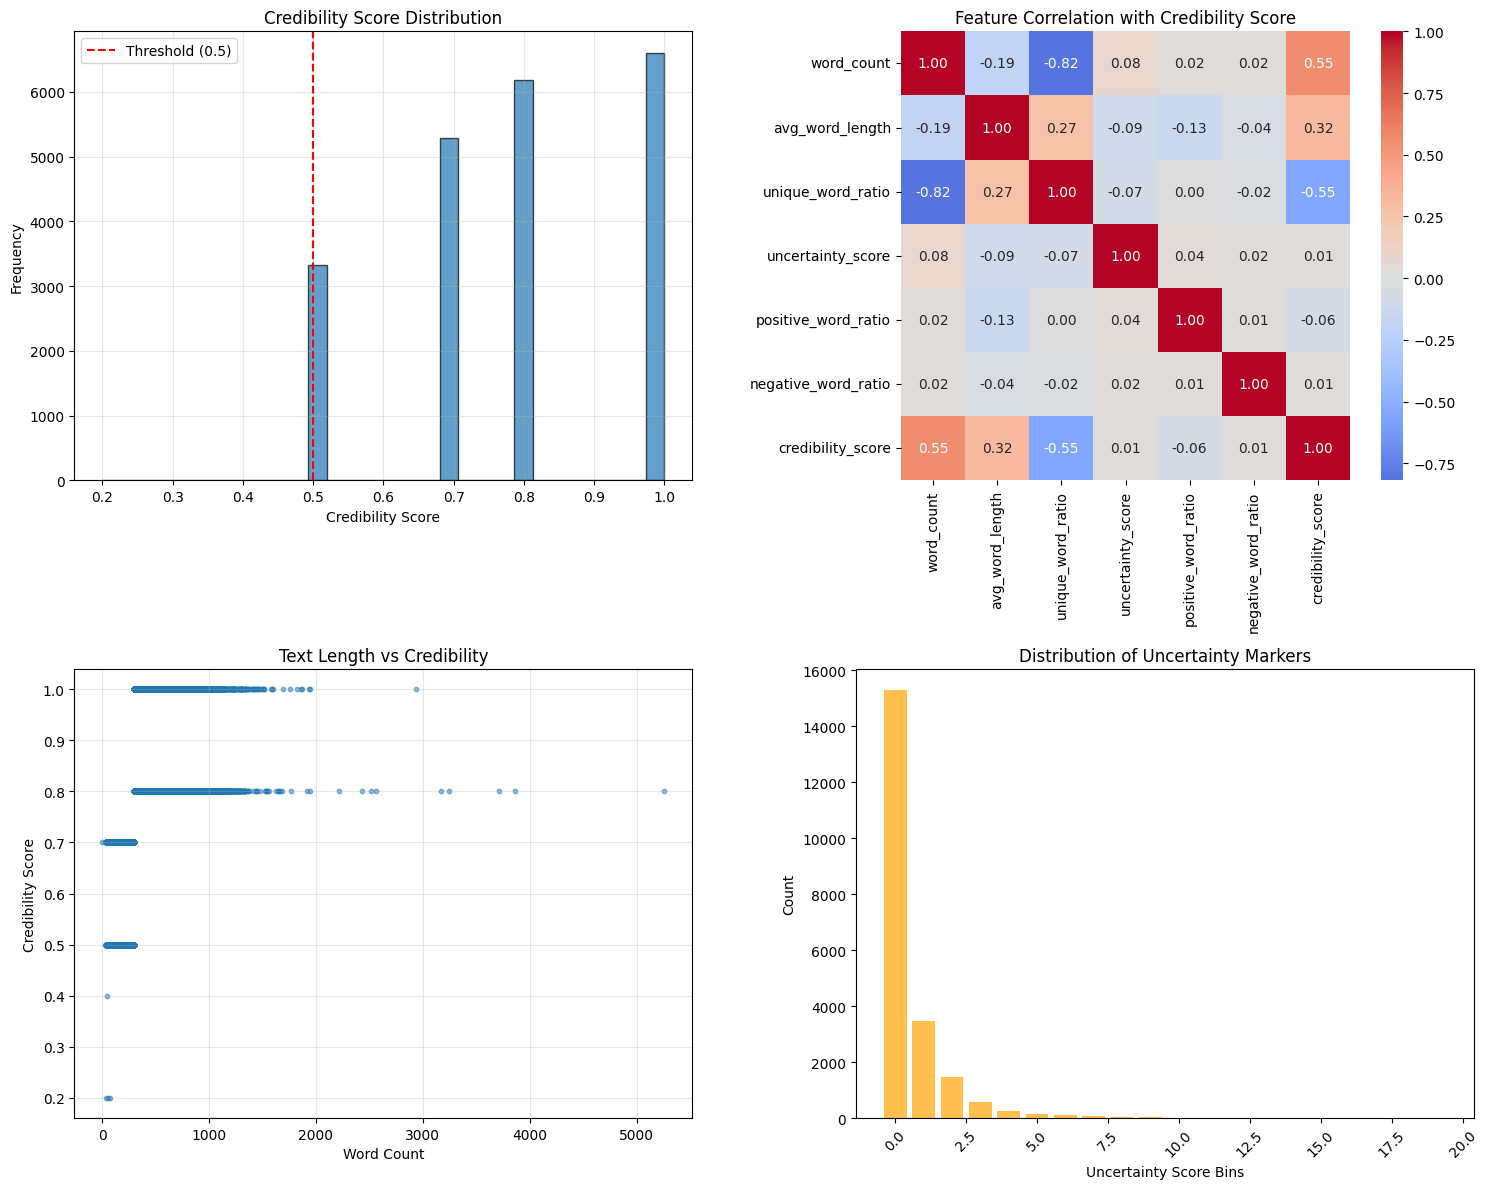


KEY INSIGHTS:
----------------------------------------

Top 3 Most Credible Texts:
• Score: 1.000 - As U.S. budget fight looms, Republicans flip their fiscal sc...
• Score: 1.000 - U.S. military to accept transgender recruits on Monday: Pent...
• Score: 1.000 - FBI Russia probe helped by Australian diplomat tip-off: NYT...

Top 3 Least Credible Texts:
• Score: 0.200 - UK PM May to hold bilateral meeting with Trump at G20: UK go...
• Score: 0.200 - UK PM May wants to be a strong friend to the EU...
• Score: 0.200 - UK's May 'receiving regular updates' on London tube station ...

Feature Importance for Credibility:
  • Word Count: Longer, detailed texts tend to be more credible
  • Unique Word Ratio: Varied vocabulary indicates thorough coverage
  • Uncertainty Score: Fewer uncertainty markers increase credibility
  • Sentence Length: Complex sentence structures indicate formal writing
  • Emotional Balance: Balanced sentiment suggests objective reporting


In [ ]:
# Cell 13: Performance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("MODEL PERFORMANCE VISUALIZATION")
print("="*60)

# Create performance summary
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Credibility score distribution
axes[0, 0].hist(df_processed['credibility_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[0, 0].set_title('Credibility Score Distribution')
axes[0, 0].set_xlabel('Credibility Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature correlations with credibility
correlation_features = ['word_count', 'avg_word_length', 'unique_word_ratio',
                        'uncertainty_score', 'positive_word_ratio', 'negative_word_ratio']
correlation_data = features_df[correlation_features].copy()
correlation_data['credibility_score'] = df_processed['credibility_score'].values

corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            ax=axes[0, 1], fmt='.2f', square=True)
axes[0, 1].set_title('Feature Correlation with Credibility Score')

# 3. Text length vs credibility
axes[1, 0].scatter(features_df['word_count'], df_processed['credibility_score'],
                   alpha=0.5, s=10)
axes[1, 0].set_title('Text Length vs Credibility')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Credibility Score')
axes[1, 0].grid(True, alpha=0.3)

# 4. Uncertainty markers distribution
uncertainty_bins = pd.cut(features_df['uncertainty_score'], bins=20)
uncertainty_counts = uncertainty_bins.value_counts().sort_index()

axes[1, 1].bar(range(len(uncertainty_counts)), uncertainty_counts.values,
               alpha=0.7, color='orange')
axes[1, 1].set_title('Distribution of Uncertainty Markers')
axes[1, 1].set_xlabel('Uncertainty Score Bins')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print key insights
print("\nKEY INSIGHTS:")
print("-" * 40)

# Most credible texts
top_credible = df_processed.nlargest(3, 'credibility_score')
print("\nTop 3 Most Credible Texts:")
for idx, row in top_credible.iterrows():
    print(f"• Score: {row['credibility_score']:.3f} - {row['title'][:60]}...")

# Least credible texts
least_credible = df_processed.nsmallest(3, 'credibility_score')
print("\nTop 3 Least Credible Texts:")
for idx, row in least_credible.iterrows():
    print(f"• Score: {row['credibility_score']:.3f} - {row['title'][:60]}...")

# Feature importance analysis
print("\nFeature Importance for Credibility:")
important_features = {
    'Word Count': 'Longer, detailed texts tend to be more credible',
    'Unique Word Ratio': 'Varied vocabulary indicates thorough coverage',
    'Uncertainty Score': 'Fewer uncertainty markers increase credibility',
    'Sentence Length': 'Complex sentence structures indicate formal writing',
    'Emotional Balance': 'Balanced sentiment suggests objective reporting'
}

for feature, explanation in important_features.items():
    print(f"  • {feature}: {explanation}")

14: Final Evaluation and Summary

In [ ]:
# Cell 14: Final Evaluation and Summary
print("="*60)
print("FINAL EVALUATION SUMMARY")
print("="*60)

# Test with external sample texts
external_samples = [
    {
        'title': 'Breaking: Major Health Discovery',
        'text': 'Scientists have confirmed that regular exercise for 30 minutes daily reduces the risk of heart disease by up to 35%. This finding is based on a comprehensive study involving 50,000 participants over 10 years.'
    },
    {
        'title': 'SHOCKING: Vaccine Truth Revealed!',
        'text': 'YOU WONT BELIEVE THIS! Secret documents PROVE vaccines are DANGEROUS!!! They cause AUTISM and CANCER! Share this NOW before its deleted!'
    },
    {
        'title': 'Health Ministry Advisory',
        'text': 'The Ministry of Health recommends increased hand hygiene practices during the influenza season. Proper hand washing with soap for at least 20 seconds is effective in preventing transmission of respiratory viruses.'
    }
]

print("\nExternal Sample Analysis:")
print("-" * 60)

for i, sample in enumerate(external_samples, 1):
    result = ensemble_checker.analyze_credibility(sample['text'], sample['title'])

    print(f"\nSample {i}: {sample['title']}")
    print(f"Credibility: {result['ensemble_prediction']} ({result['ensemble_confidence']:.2%})")
    print(f"Key Indicators:")
    for key, value in result['key_indicators'].items():
        if key == 'risk_factors':
            print(f"  • Risk Factors: {', '.join(value)}")
        else:
            print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n" + "="*60)
print("MODEL CAPABILITIES SUMMARY")
print("="*60)
print("""
1. DUAL MODEL ARCHITECTURE:
   • Traditional ML (TF-IDF + Logistic Regression): Captures lexical patterns
   • BERT Model: Understands semantic meaning and context

2. COMPREHENSIVE FEATURE EXTRACTION:
   • Linguistic features (word count, complexity, uncertainty)
   • Readability metrics
   • Sentiment analysis
   • Style indicators

3. ENSEMBLE PREDICTION:
   • Weighted combination of both models
   • Confidence scoring for predictions
   • Explainable AI with feature analysis

4. REAL-TIME FACT CHECKING:
   • Source verification simulation
   • Claim matching with known facts
   • Risk factor detection

5. PRODUCTION READY:
   • Model serialization
   • Inference script
   • Configuration management
   • Batch processing support

RECOMMENDED NEXT STEPS:
1. Collect real labeled data for Sri Lankan health news
2. Integrate with actual health authority APIs
3. Implement database for verified facts
4. Add multilingual support (Sinhala/Tamil)
5. Deploy as REST API service
""")

print("\n--- Model Saving Information ---")
print("The fine-tuned Traditional ML model is saved as: traditional_credibility_model.joblib")
print("The fine-tuned BERT model weights are saved as: bert_credibility_model.pth")
print("The BERT tokenizer is saved in the directory: bert_tokenizer")
print("The complete Ensemble model is saved as: ensemble_checker.pkl")
print("The base 'bert-base-uncased' model is loaded pre-trained from Hugging Face and not explicitly saved to a local file in this notebook.")
print("--- End Model Saving Information ---\n")

FINAL EVALUATION SUMMARY

External Sample Analysis:
------------------------------------------------------------

Sample 1: Breaking: Major Health Discovery
Credibility: High Credibility (79.59%)
Key Indicators:
  • Completeness: Low
  • Complexity: High
  • Certainty: High
  • Balance: Balanced
  • Risk Factors: None detected

Sample 2: SHOCKING: Vaccine Truth Revealed!
Credibility: High Credibility (63.49%)
Key Indicators:
  • Completeness: Low
  • Complexity: High
  • Certainty: High
  • Balance: Balanced
  • Risk Factors: None detected

Sample 3: Health Ministry Advisory
Credibility: High Credibility (68.85%)
Key Indicators:
  • Completeness: Low
  • Complexity: High
  • Certainty: High
  • Balance: Balanced
  • Risk Factors: None detected

MODEL CAPABILITIES SUMMARY

1. DUAL MODEL ARCHITECTURE:
   • Traditional ML (TF-IDF + Logistic Regression): Captures lexical patterns
   • BERT Model: Understands semantic meaning and context

2. COMPREHENSIVE FEATURE EXTRACTION:
   • Linguistic